# 04 Model Development and Evaluation

This notebook trains and evaluates multiple machine learning models for customer churn prediction.

The objectives are to:

- load the feature-engineered datasets
- train multiple classification models
- evaluate model performance using consistent metrics
- compare models using validation data
- select a champion model for later interpretation and business recommendation

This notebook reproduces the model comparison stage of the original SAS Viya workflow using Python and scikit-learn.

## 1. Import Libraries

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load Feature-Engineered Datasets

The machine-learning-ready datasets created in Notebook 3 are loaded from the `data/processed/` directory.

In [80]:
X_train = pd.read_csv("../data/processed/X_train_balanced.csv")
y_train = pd.read_csv("../data/processed/y_train_balanced.csv").squeeze()

X_valid = pd.read_csv("../data/processed/X_valid.csv")
y_valid = pd.read_csv("../data/processed/y_valid.csv").squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")

X_train shape: (11898, 32)
y_train shape: (11898,)
X_valid shape: (3039, 32)
y_valid shape: (3039,)


## 3. Dataset Validation

Before training models, the training and validation datasets are checked to ensure that they contain aligned features and valid target values.

In [81]:
validation_checks = pd.DataFrame({
    "Check": [
        "Training and validation columns aligned",
        "Training missing values",
        "Validation missing values",
        "Training target classes",
        "Validation target classes"
    ],
    "Result": [
        list(X_train.columns) == list(X_valid.columns),
        X_train.isna().sum().sum(),
        X_valid.isna().sum().sum(),
        sorted(y_train.unique().tolist()),
        sorted(y_valid.unique().tolist())
    ]
})

validation_checks

,Check,Result
0,Training and validation columns aligned,True
1,Training missing values,0
2,Validation missing values,0
3,Training target classes,"[0, 1]"
4,Validation target classes,"[0, 1]"


## 4. Model Training Strategy

Five widely used supervised machine learning algorithms are evaluated to identify the most effective model for customer churn prediction.

The selected models represent a diverse range of modelling approaches, from linear classification to tree-based ensembles and kernel-based learning, enabling a comprehensive comparison of predictive performance.

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- Support Vector Machine

All models are trained on the balanced training dataset and evaluated on the original validation dataset.

### Model Specific Preprocessing

Feature standardisation is applied only to the Logistic Regression model. Linear models optimise their parameters using gradient-based algorithms and are sensitive to differences in feature scales, which can affect convergence and model performance. Standardising the predictors places all numerical variables on a comparable scale, allowing the optimisation algorithm to converge more efficiently.

In contrast, tree-based algorithms (Decision Tree, Random Forest, and Gradient Boosting) partition data based on feature thresholds rather than distances or gradient magnitudes. Their predictions are therefore largely unaffected by the scale of the input variables, making feature standardisation unnecessary. To preserve consistency with the original SAS Viya workflow and avoid unnecessary preprocessing, these models are trained using the original feature scales.

## 5. Model Initialisation

Five commonly used supervised machine learning algorithms are initialised using reproducible hyperparameters.

Logistic Regression is implemented using a standardisation pipeline because linear models are sensitive to feature scale.

These models were selected to represent a diverse range of classification techniques:

- Logistic Regression — Linear baseline classifier
- Decision Tree — Interpretable tree-based model
- Random Forest — Bagging ensemble model
- Gradient Boosting — Sequential boosting ensemble
- Support Vector Machine — Margin-based classifier

A fixed random seed (`random_state=42`) is used where applicable to ensure reproducibility.

In [82]:
models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(random_state=42, max_iter=1000)),
        ]
    ),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
}

print(f"{len(models)} models initialised.")

for model in models:
    print(f"Successfully built: {model}")

5 models initialised.
Successfully built: Logistic Regression
Successfully built: Decision Tree
Successfully built: Random Forest
Successfully built: Gradient Boosting
Successfully built: Support Vector Machine


## 6. Model Training

Each model is trained using the balanced training dataset prepared in Notebook 3.

Training is performed independently for each algorithm while maintaining identical training data to ensure a fair comparison during model evaluation.

In [83]:
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

print("\nAll models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...


Training Gradient Boosting...
Training Support Vector Machine...

All models trained successfully.


The models are trained using the balanced training dataset to mitigate class imbalance during learning, while evaluation is performed on the original validation dataset to provide an unbiased estimate of real-world performance.

## 7. Model Evaluation

Each trained model is evaluated on the original validation dataset.

The following evaluation metrics are calculated to provide a comprehensive assessment of predictive performance:

- **Accuracy** – Measures the overall proportion of correctly classified customers. While useful as a general performance indicator, accuracy alone may be misleading for imbalanced datasets such as customer churn prediction.

- **Precision** – Measures the proportion of customers predicted to churn who actually churned. High precision reduces false positive predictions, helping avoid unnecessary retention efforts on customers who are unlikely to leave.

- **Recall** – Measures the proportion of actual churned customers that were correctly identified. High recall is particularly important in churn prediction because failing to identify customers who are likely to leave represents a missed opportunity for intervention.

- **F1-score** – The harmonic mean of precision and recall. It provides a balanced measure when both false positives and false negatives are important considerations.

- **ROC AUC** – Measures the model's ability to distinguish between churned and non-churned customers across all classification thresholds. Unlike accuracy, ROC AUC evaluates the model's ranking capability and is widely regarded as one of the most reliable metrics for comparing binary classification models.

Together, these complementary metrics provide a balanced assessment of predictive performance and support the identification of the most suitable model for customer churn prediction.

In [84]:
results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_valid)

    y_prob = model.predict_proba(X_valid)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1 Score": f1_score(y_valid, y_pred),
        "ROC AUC": roc_auc_score(y_valid, y_prob)
    })

results = pd.DataFrame(results)

results = results.sort_values(
    "ROC AUC",
    ascending=False
).reset_index(drop=True)

results_display = results.copy()

metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

results_display[metric_cols] = results_display[metric_cols].round(4)

results_display

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Gradient Boosting,0.9543,0.8088,0.9365,0.8680,0.9889
1,Random Forest,0.9506,0.8824,0.7992,0.8387,0.9847
2,Logistic Regression,0.8536,0.5280,0.8299,0.6454,0.9218
3,Support Vector Machine,0.8138,0.4549,0.8053,0.5814,0.8796
4,Decision Tree,0.9329,0.8060,0.7664,0.7857,0.8656


### Evaluation Findings

Gradient Boosting achieved the strongest overall validation performance, with the highest ROC AUC (**0.9889**) and F1-score (**0.8680**). It also produced the highest recall (**0.9365**), indicating that it was the most effective model for identifying customers who are likely to churn.

Random Forest achieved the highest precision (**0.8824**) and strong ROC AUC (**0.9847**), meaning it was more conservative in predicting churn but made fewer false positive churn predictions.

Logistic Regression and Support Vector Machine achieved reasonable ROC AUC values but substantially lower precision and F1-scores, suggesting weaker practical performance for churn intervention. Decision Tree performed well in accuracy but had the lowest ROC AUC among the evaluated models, indicating weaker ranking ability compared with the ensemble models.

Overall, Gradient Boosting is the leading candidate for the champion model because it provides the best balance between discrimination ability, recall, and F1-score, which are important for identifying at-risk customers in a churn prediction setting.

## 8. Receiver Operating Characteristic (ROC) Curve Comparison

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate across different classification thresholds.

Unlike accuracy, which evaluates predictions at a single threshold, the ROC curve assesses model discrimination across all possible thresholds.

The Area Under the ROC Curve (ROC AUC) summarises this performance into a single value ranging from 0 to 1, where higher values indicate stronger ability to distinguish between churned and non-churned customers.

Comparing ROC curves provides a visual assessment of the relative performance of each classification model.

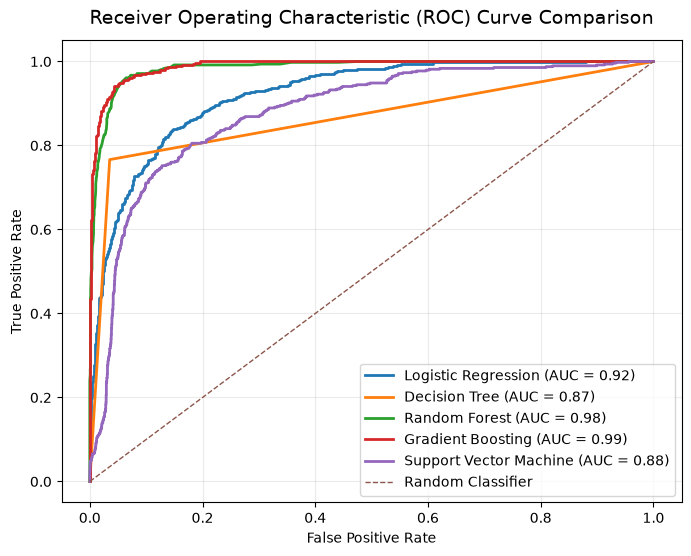

In [85]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_valid)[:, 1]

    fpr, tpr, _ = roc_curve(y_valid, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.2f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random Classifier"
)

plt.title(
    "Receiver Operating Characteristic (ROC) Curve Comparison",
    fontsize=14,
    pad=12
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)

plt.show()

### ROC Curve Findings

The ROC curves demonstrate clear differences in discrimination performance across the five classification models.

Gradient Boosting achieved the highest ROC AUC (**0.99**), with its ROC curve remaining closest to the upper-left corner throughout the entire threshold range. This indicates the strongest ability to distinguish between customers who are likely to churn and those who are not.

Random Forest closely followed with a ROC AUC of **0.98**, producing a very similar curve and demonstrating excellent classification capability. Both ensemble methods substantially outperformed the remaining models.

Logistic Regression achieved a moderate ROC AUC of **0.92**, indicating reasonable predictive performance despite its simpler linear decision boundary. In contrast, Support Vector Machine (**0.88**) and Decision Tree (**0.87**) exhibited noticeably weaker discrimination performance, as reflected by their ROC curves lying further from the ideal upper-left region.

Overall, the ROC analysis confirms that **Gradient Boosting** provides the strongest overall classification performance and reinforces its selection as the leading candidate for the champion model.

## 9. Confusion Matrix Comparison

While aggregate evaluation metrics provide an overall assessment of model performance, the confusion matrix reveals the exact prediction outcomes for each classifier.

For customer churn prediction, the four outcomes are:

- **True Positive (TP):** Correctly identifies customers who churn.
- **True Negative (TN):** Correctly identifies customers who remain.
- **False Positive (FP):** Incorrectly predicts churn for customers who remain.
- **False Negative (FN):** Fails to identify customers who actually churn.

From a business perspective, false negatives are generally more costly because they represent customers who leave without receiving any retention intervention. Therefore, the confusion matrices provide valuable insight into the practical trade-offs made by each classification model.

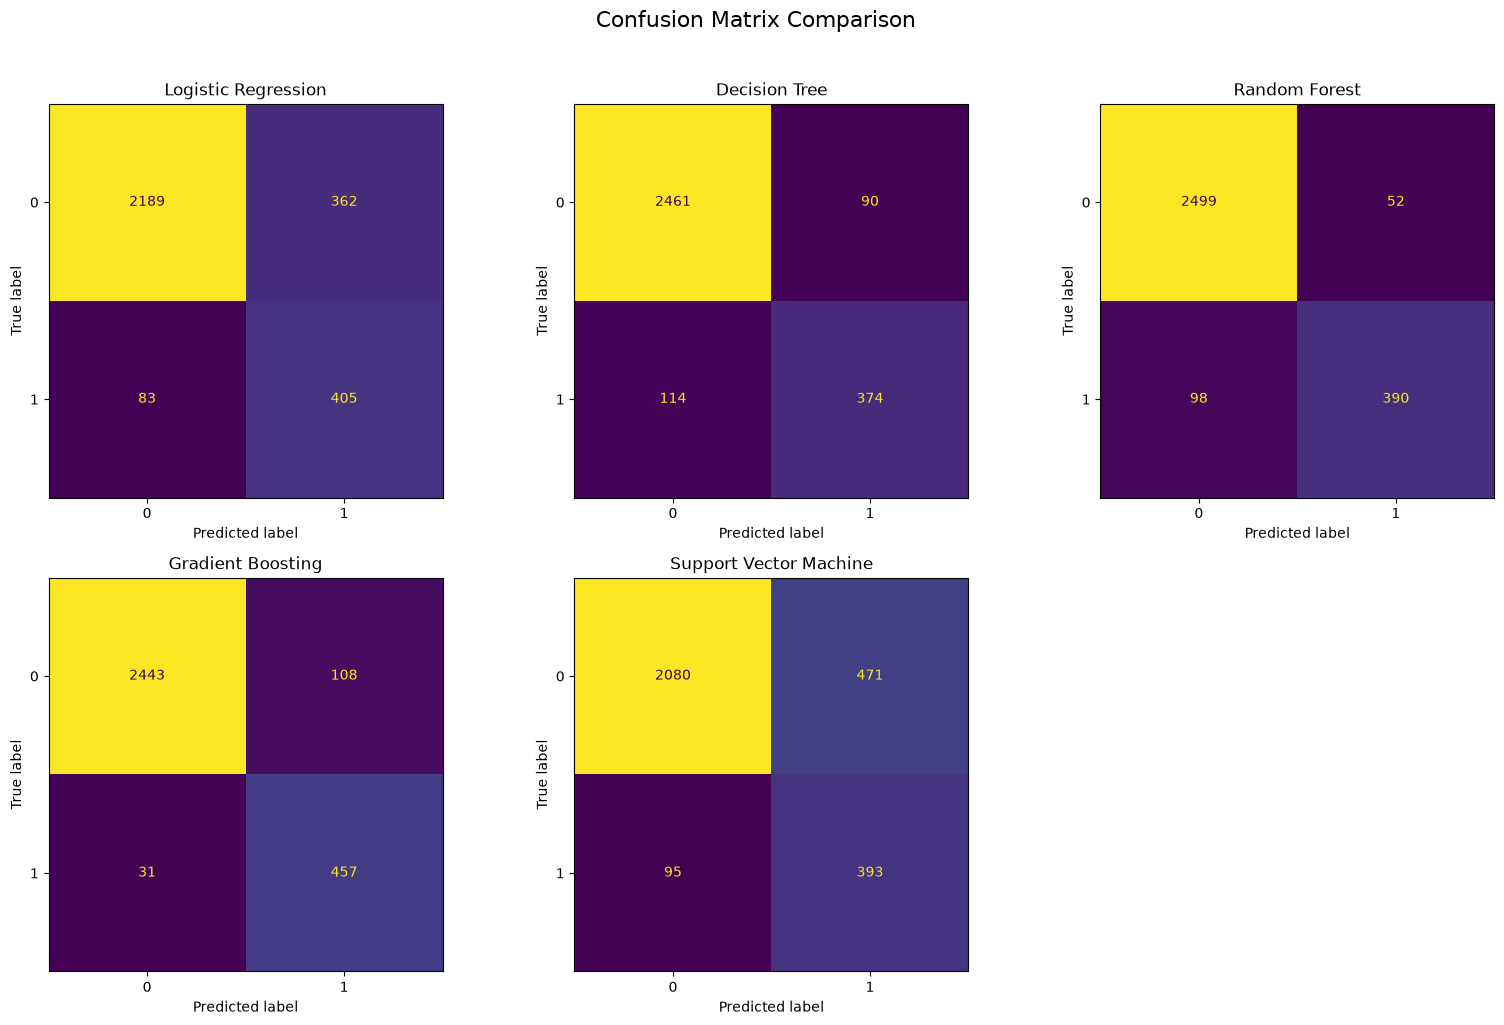

In [86]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes = axes.flatten()

for ax, (name, model) in zip(axes, trained_models.items()):

    y_pred = model.predict(X_valid)

    ConfusionMatrixDisplay.from_predictions(
        y_valid,
        y_pred,
        ax=ax,
        colorbar=False
    )

    ax.set_title(name)

# Remove unused subplot
fig.delaxes(axes[-1])

plt.suptitle(
    "Confusion Matrix Comparison",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.show()

### Confusion Matrix Findings

The confusion matrices provide a detailed view of the prediction outcomes for each classification model and highlight the trade-offs between identifying churned customers and minimising false alarms.

Gradient Boosting achieved the strongest overall balance between correctly identifying churned customers and avoiding unnecessary churn predictions. It produced the **fewest false negatives (31)** while maintaining a relatively low number of **false positives (108)**, indicating that it was highly effective at identifying customers who were genuinely at risk of leaving.

Random Forest generated the **fewest false positives (52)** among all models, demonstrating excellent precision by minimising incorrect churn predictions. However, this came at the cost of identifying fewer actual churned customers, resulting in **98 false negatives**.

Logistic Regression identified a large proportion of churned customers (**83 false negatives**) but produced a substantially higher number of **false positives (362)**, suggesting that many loyal customers would be unnecessarily targeted for retention campaigns.

Support Vector Machine exhibited a similar pattern, generating the highest number of **false positives (471)** while still missing **95 churned customers**, resulting in the weakest practical performance despite its reasonable ROC AUC.

Decision Tree produced relatively balanced predictions but generated **114 false negatives**, indicating that more churned customers would remain undetected compared with the ensemble models.

Overall, the confusion matrices reinforce the earlier quantitative evaluation by demonstrating that **Gradient Boosting provides the most favourable trade-off between identifying customers at risk of churn and minimising incorrect retention efforts**, making it the most suitable candidate for deployment.

## 10. Feature Importance Analysis

Understanding which variables contribute most to model predictions is essential for translating machine learning results into actionable business insights.

Feature importance is available only for tree-based models because these algorithms estimate the contribution of each predictor by measuring how much it reduces classification error during tree construction. Linear models such as Logistic Regression use model coefficients instead, while Support Vector Machine does not provide native feature importance scores.

Therefore, this analysis focuses on the following tree-based models:

- Decision Tree
- Random Forest
- Gradient Boosting

Comparing these models helps determine whether important predictors remain consistent across different ensemble learning techniques.

In [87]:
def plot_feature_importance(model, model_name, top_n=15):

    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": model.feature_importances_
    })

    importance = (
        importance
        .sort_values("Importance", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(8,6))

    plt.barh(
        importance["Feature"],
        importance["Importance"]
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Importance")

    plt.title(f"{model_name} Feature Importance")

    plt.grid(axis="x", alpha=0.3)

    plt.show()

    return importance

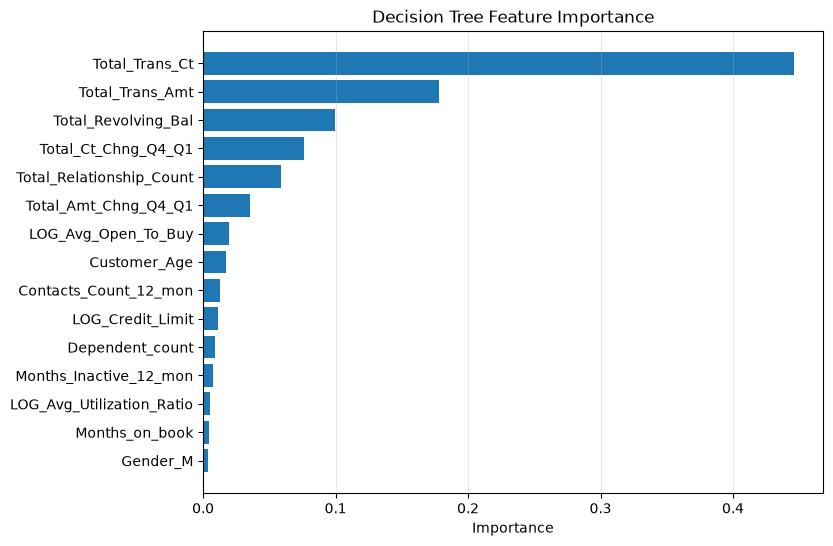

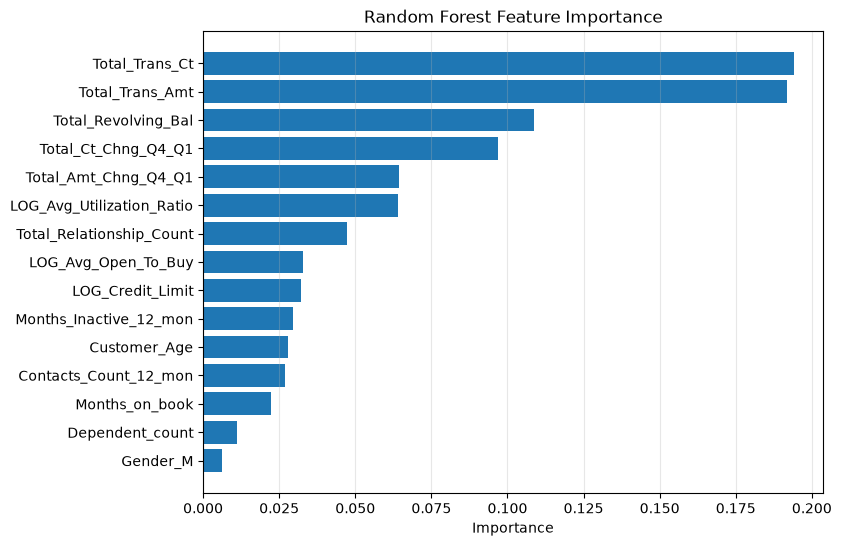

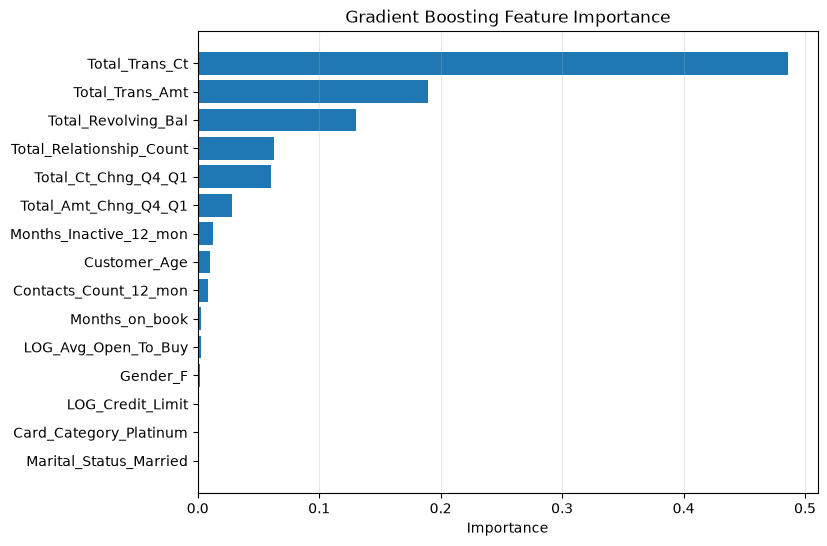

In [88]:
dt_importance = plot_feature_importance(
    trained_models["Decision Tree"],
    "Decision Tree"
)

rf_importance = plot_feature_importance(
    trained_models["Random Forest"],
    "Random Forest"
)

gb_importance = plot_feature_importance(
    trained_models["Gradient Boosting"],
    "Gradient Boosting"
)

### Comparison of Important Predictors

To assess whether different tree-based algorithms identify similar patterns, the top-ranked predictors from each model are compared side by side.

Consistent rankings across models increase confidence that these variables genuinely influence customer churn rather than reflecting model-specific behaviour.

In [89]:
comparison = pd.DataFrame({
    "Decision Tree": dt_importance["Feature"].values,
    "Random Forest": rf_importance["Feature"].values,
    "Gradient Boosting": gb_importance["Feature"].values
})

comparison.index = comparison.index + 1
comparison.index.name = "Rank"

comparison

,Decision Tree,Random Forest,Gradient Boosting
Rank,,,
1,Total_Trans_Ct,Total_Trans_Ct,Total_Trans_Ct
2,Total_Trans_Amt,Total_Trans_Amt,Total_Trans_Amt
3,Total_Revolving_Bal,Total_Revolving_Bal,Total_Revolving_Bal
4,Total_Ct_Chng_Q4_Q1,Total_Ct_Chng_Q4_Q1,Total_Relationship_Count
5,Total_Relationship_Count,Total_Amt_Chng_Q4_Q1,Total_Ct_Chng_Q4_Q1
6,Total_Amt_Chng_Q4_Q1,LOG_Avg_Utilization_Ratio,Total_Amt_Chng_Q4_Q1
7,LOG_Avg_Open_To_Buy,Total_Relationship_Count,Months_Inactive_12_mon
8,Customer_Age,LOG_Avg_Open_To_Buy,Customer_Age
9,Contacts_Count_12_mon,LOG_Credit_Limit,Contacts_Count_12_mon


The comparison table demonstrates strong agreement among the three tree-based models, with the highest-ranked predictors appearing consistently across different algorithms.

This consistency provides greater confidence that these variables genuinely influence customer churn.

### Feature Importance Findings

The three tree-based models consistently identified customer transaction behaviour as the strongest predictor of churn.

Across all models, **Total_Trans_Ct** ranked as the most influential feature, followed by **Total_Trans_Amt** and **Total_Revolving_Bal**. These variables describe how frequently customers use their credit cards and how actively they engage with the bank's products.

Customer relationship indicators, including **Total_Relationship_Count** and **Total_Ct_Chng_Q4_Q1**, also contributed substantially to model predictions, suggesting that declining engagement and reduced banking activity are strong indicators of future customer attrition.

Conversely, demographic variables such as gender, marital status and card category contributed very little to predictive performance. This indicates that behavioural characteristics are considerably more informative than customer demographics for predicting churn.

The consistency of the most important predictors across Decision Tree, Random Forest and Gradient Boosting increases confidence that these variables genuinely drive customer attrition rather than reflecting model-specific behaviour.

## 11. Champion Model Selection

The evaluation results consistently demonstrate that Gradient Boosting provides the strongest predictive performance across multiple evaluation metrics.

Compared with the other evaluated algorithms, Gradient Boosting achieved:

- Highest ROC AUC (0.9889)
- Highest Recall (0.9365)
- Highest F1-score (0.8680)

Although Random Forest achieved the highest Precision, Gradient Boosting produced substantially fewer false negatives while maintaining excellent overall discrimination performance.

For customer churn prediction, failing to identify customers who are likely to leave represents a greater business cost than unnecessarily targeting existing customers for retention campaigns. Therefore, Gradient Boosting offers the most appropriate balance between predictive performance and business value.

Based on these findings, Gradient Boosting is selected as the champion model for subsequent model interpretation and business recommendation.

This conclusion is consistently supported by the evaluation metrics, ROC curve comparison, confusion matrices and feature importance analysis presented throughout this notebook.

## 12. Save Champion Model

The selected Gradient Boosting model is saved for deployment and further interpretability analysis in the next notebook.

In [90]:
import os

os.makedirs("../models", exist_ok=True)

champion_model = trained_models["Gradient Boosting"]

joblib.dump(
    champion_model,
    "../models/champion_model.pkl"
)

print("Champion model saved successfully.")
print("Location: ../models/champion_model.pkl")

Champion model saved successfully.
Location: ../models/champion_model.pkl


## 13. Summary

This notebook reproduced the model development and evaluation stage of the original SAS Viya workflow using Python and scikit-learn.

Five supervised machine learning algorithms—Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and Support Vector Machine—were trained using a balanced training dataset and evaluated on the original validation dataset to ensure an unbiased assessment of predictive performance.

Model comparison using Accuracy, Precision, Recall, F1-score, ROC AUC, ROC curve analysis, and confusion matrices consistently demonstrated that **Gradient Boosting** achieved the strongest overall performance. It attained the highest ROC AUC (**0.9889**), highest Recall (**0.9365**), and highest F1-score (**0.8680**), while maintaining an effective balance between identifying churned customers and minimising unnecessary retention efforts.

Feature importance analysis further revealed that customer transaction behaviour and relationship activity—particularly **Total_Trans_Ct**, **Total_Trans_Amt**, **Total_Revolving_Bal**, and **Total_Relationship_Count**—were consistently the most influential predictors across the tree-based models. In contrast, demographic characteristics contributed relatively little to predictive performance.

Based on the combined evidence from quantitative evaluation metrics, ROC analysis, confusion matrix comparison, and feature importance analysis, **Gradient Boosting** was selected as the champion model. The trained model has been saved and will be interpreted in the next notebook using SHAP and LIME to explain both global feature importance and individual customer-level predictions.